Importing Libraries

In [1]:
import torch
from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Dataset Loading

In [3]:
dataset = load_dataset('imdb')

In [4]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


Tokenizer

In [5]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

Tokenization function

In [6]:
def tokenize(example):
    return tokenizer(
        example['text'],
        padding = 'max_length',
        truncation = True,
        max_length = 256
    )

In [7]:
dataset = dataset.map(tokenize, batched=True)

In [ ]:
print(dataset['train'][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

Dataset convertion

In [9]:
dataset.set_format(
    type = 'torch',
    columns = ['input_ids', 'attention_mask', 'label']
)

In [10]:
sample = dataset['train'][0]

print(type (sample['input_ids']))
print(sample['input_ids'].shape)

<class 'torch.Tensor'>
torch.Size([256])


Data Loader

In [11]:
train_loader = DataLoader(dataset['train'], batch_size=8, shuffle=True)
test_loader = DataLoader(dataset['test'], batch_size=8)

In [12]:
batch = next(iter(train_loader))

print(batch.keys())
print(batch['input_ids'].shape)

dict_keys(['label', 'input_ids', 'attention_mask'])
torch.Size([8, 256])


Loading Model

In [13]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels =2
)

model.to(device)

print(model)    

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

Training

In [14]:
optimizer =AdamW(model.parameters(), lr= 2e-5)

In [21]:
train_losses = []

num_epochs = 3

for epoch in range(num_epochs):
    model.train()

    total_loss = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids = input_ids,
            attention_mask = attention_mask,
            labels = labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()

        optimizer.step()
    
    avg_loss = total_loss/ len(train_loader)
    train_losses.append(avg_loss)
        
    print(f"Epoch {epoch+1}, Loss: {avg_loss}")
        

Epoch 1, Loss: 0.13291520734488965
Epoch 2, Loss: 0.06750849984811619
Epoch 3, Loss: 0.043565980838090185


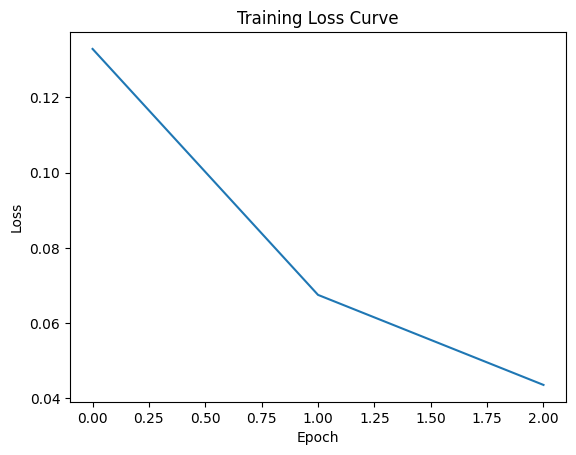

In [22]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [23]:
model.eval()

preds = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        
        predictions = torch.argmax(logits, dim=1)
        
        preds.extend(predictions.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

In [24]:
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:", accuracy_score(true_labels, preds))
print("F1 Score:", f1_score(true_labels, preds))

Accuracy: 0.91276
F1 Score: 0.9153305640746923


In [25]:
save_path = "saved_model"

model.save_pretrained(save_path)

tokenizer.save_pretrained(save_path)

print(f"Model saved to {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to saved_model


Inference

In [28]:
def predict(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation = True,
        padding = True,
        max_length = 256
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        pred = torch.argmax(logits, dim=1).item()

    return 'Positive' if pred==1 else "Negative"

In [30]:
predict('A good movie, although some scenes were boring')

'Positive'